# Эмоциональный классификатор для финансовых текстов Telegram

**ВКР:** «Эмоциональные индикаторы в Telegram-каналах как фактор краткосрочного прогнозирования инфляции в России»

**Этап 1 — Baseline:** дообучение `cointegrated/rubert-tiny2` на 4 классах эмоций (Anxiety, Aggression, Hope, Neutral), размеченных моделью GigaChat по 9 583 текстам из 6 финансовых Telegram-каналов.

**Архитектура решения:** teacher-student knowledge distillation (Hinton et al., 2015). GigaChat — учитель, rubert-tiny2 — ученик. Подход апробирован для финансового NLP в Araci (2019) FinBERT и Shapiro et al. (2022) при анализе коммуникаций ФРС.

**Что в ноутбуке:**
1. Подготовка данных: дедупликация, очистка, стратифицированный split (channel × emotion)
2. Обучение rubert-tiny2 со взвешенным CrossEntropyLoss
3. Калибровка вероятностей через temperature scaling
4. LOCO cross-validation (leave-one-channel-out) — оценка робастности
5. Инференс на полном корпусе с сохранением вероятностей всех классов
6. Агрегация в дневные временные ряды эмоций (для DFM/MFBVAR)

**Среда:** Google Colab Free (T4 GPU, 15 GB VRAM). Время полного прогона: ~2.5 часа.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q -U --force-reinstall numpy scipy scikit-learn
!pip install -q -U transformers datasets accelerate pandas tqdm pyarrow matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 14.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

## 0. Установка зависимостей и проверка GPU

In [ ]:
!pip install -q -U numpy pandas transformers datasets accelerate scikit-learn tqdm pyarrow

In [ ]:
import torch
import numpy as np
import pandas as pd
import random

# Воспроизводимость — фиксируем все сиды (важно для академической работы)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Загрузка и диагностика данных

Загружаем размеченный GigaChat суб-датасет. Если работаешь в Colab — загрузи файл через `files.upload()` или подключи Google Drive.

In [ ]:
# Вариант 1: через локальную загрузку
# from google.colab import files
# uploaded = files.upload()


DATA_PATH = '/content/drive/MyDrive/diploma/labeled gigachat.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (9583, 10)


,type,channel,date,text,views,reactions_count,post_id,reply_to_post_id,clean_text,emotion
0,comment,centralbank_russia,2023-06-19 16:56:25+00:00,Почему же тогда ФРС таргетирет не только инфля...,0,0,14143,1117.0,Почему же тогда ФРС таргетирет не только инфля...,Neutral
1,comment,Coin_Post,2025-07-24 15:47:41+00:00,Не собирается что?),0,0,1913688,16192.0,Не собирается что?),Aggression
2,comment,spydell_finance,2022-10-14 19:36:04+00:00,"Вообще занятная вещь, если почитать хроники за...",0,0,310756,2056.0,"Вообще занятная вещь, если почитать хроники за...",Neutral


In [ ]:
# Базовая статистика — должна совпасть с тем, что мы видели на этапе диагностики
print('Распределение эмоций:')
print(df['emotion'].value_counts())
print(f"\nДоли: \n{(df['emotion'].value_counts(normalize=True) * 100).round(2)}")
print(f'\nКаналы: {df["channel"].nunique()}')
print(df['channel'].value_counts())

Распределение эмоций:
emotion
Neutral       4874
Anxiety       2484
Aggression    1710
Hope           515
Name: count, dtype: int64

Доли: 
emotion
Neutral       50.86
Anxiety       25.92
Aggression    17.84
Hope           5.37
Name: proportion, dtype: float64

Каналы: 6
channel
spydell_finance       5516
Coin_Post             1936
centralbank_russia     898
swaneconomy            677
bitkogan               280
russianmacro           276
Name: count, dtype: int64


## 2. Очистка и подготовка к обучению

**Что делаем:**
- Удаляем точные дубликаты `clean_text` (35 шт. в нашем датасете)
- Удаляем пустые/слишком короткие тексты (< 3 символов — это шум)
- Кодируем эмоции в числовые метки
- Создаём id2label / label2id для последующего инференса

In [ ]:
before = len(df)
df = df.dropna(subset=['clean_text', 'emotion'])
df = df[df['clean_text'].astype(str).str.len() >= 3]
df = df.drop_duplicates(subset=['clean_text']).reset_index(drop=True)
print(f'После очистки: {len(df)} строк (удалено {before - len(df)})')

# Маппинг меток
EMOTIONS = sorted(df['emotion'].unique().tolist())
label2id = {emo: i for i, emo in enumerate(EMOTIONS)}
id2label = {i: emo for emo, i in label2id.items()}
df['label'] = df['emotion'].map(label2id)
print(f'\nКлассы: {EMOTIONS}')
print(f'label2id: {label2id}')

После очистки: 9531 строк (удалено 52)

Классы: ['Aggression', 'Anxiety', 'Hope', 'Neutral']
label2id: {'Aggression': 0, 'Anxiety': 1, 'Hope': 2, 'Neutral': 3}


## 3. Стратифицированный split: train / val / test

**Стратификация по составной метке `channel × emotion`** — это ключевой методологический момент.
Если просто разделить рандомно или только по эмоции, мы рискуем получить, например, что весь Coin_Post окажется в test, а в train его не будет вовсе. Тогда модель не увидит этот стиль на обучении и просядет на нём в инференсе.

Размеры: 70/15/15 — стандартный академический split.

In [ ]:
from sklearn.model_selection import train_test_split

df['stratify_key'] = df['channel'].astype(str) + '__' + df['emotion'].astype(str)

# Сначала отделяем test (15%)
df_trainval, df_test = train_test_split(
    df, test_size=0.15, random_state=SEED,
    stratify=df['stratify_key']
)

# Из оставшихся 85% отделяем val (15/85 ≈ 17.6%, чтобы val было 15% от исходного)
df_train, df_val = train_test_split(
    df_trainval, test_size=0.176, random_state=SEED,
    stratify=df_trainval['stratify_key']
)

for name, d in [('train', df_train), ('val', df_val), ('test', df_test)]:
    print(f'{name}: {len(d)} | распределение эмоций:')
    print((d['emotion'].value_counts(normalize=True) * 100).round(1).to_dict())
    print()

train: 6675 | распределение эмоций:
{'Neutral': 50.7, 'Anxiety': 26.0, 'Aggression': 17.9, 'Hope': 5.3}

val: 1426 | распределение эмоций:
{'Neutral': 50.8, 'Anxiety': 26.0, 'Aggression': 17.9, 'Hope': 5.3}

test: 1430 | распределение эмоций:
{'Neutral': 50.8, 'Anxiety': 26.0, 'Aggression': 18.0, 'Hope': 5.2}



## 4. Подготовка датасетов и токенизация

**Модель:** `cointegrated/rubert-tiny2` (29M параметров).
Это дистиллированная версия BERT для русского языка. На наших коротких текстах (медиана 14 слов) даёт качество, сопоставимое с base-моделями, при этом обучается в 10 раз быстрее.

**max_length = 256** — покрывает 95% наших текстов (см. диагностику).

In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = 'cointegrated/rubert-tiny2'
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf_dataset(df_):
    return Dataset.from_pandas(
        df_[['clean_text', 'label']].rename(columns={'clean_text': 'text'}),
        preserve_index=False
    )

ds_train = to_hf_dataset(df_train)
ds_val = to_hf_dataset(df_val)
ds_test = to_hf_dataset(df_test)

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False  # padding делаем через DataCollator (динамически — экономит память)
    )

ds_train = ds_train.map(tokenize_fn, batched=True)
ds_val = ds_val.map(tokenize_fn, batched=True)
ds_test = ds_test.map(tokenize_fn, batched=True)
print('Токенизация завершена.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/6675 [00:00<?, ? examples/s]

Map:   0%|          | 0/1426 [00:00<?, ? examples/s]

Map:   0%|          | 0/1430 [00:00<?, ? examples/s]

Токенизация завершена.


## 5. Веса классов для борьбы с дисбалансом

У нас Neutral 51%, Hope 5% — без взвешивания модель будет переоценивать Neutral. Используем стандартную формулу `n_samples / (n_classes * n_class_samples)` (sklearn-style).

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(EMOTIONS)),
    y=df_train['label'].values
)
class_weights = torch.tensor(class_weights_array, dtype=torch.float).to(device)
print('Веса классов:')
for emo, w in zip(EMOTIONS, class_weights_array):
    print(f'  {emo}: {w:.3f}')

Веса классов:
  Aggression: 1.393
  Anxiety: 0.961
  Hope: 4.714
  Neutral: 0.493


## 6. Кастомный Trainer со взвешенным loss

In [ ]:
from transformers import (
    AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from sklearn.metrics import f1_score, precision_recall_fscore_support, accuracy_score

class WeightedTrainer(Trainer):
    """Trainer с взвешенным CrossEntropyLoss для несбалансированных классов."""
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    """Главная метрика — macro-F1 (даёт равный вес всем классам, важно при дисбалансе)."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1,
        'f1_weighted': f1_score(labels, preds, average='weighted', zero_division=0),
        'precision_macro': p,
        'recall_macro': r,
    }

## 7. Обучение модели

**Гиперпараметры подобраны под T4 + наш объём данных:**
- `learning_rate=3e-5` — стандарт для дообучения BERT-like моделей
- `batch_size=32` — комфортно помещается в 15 GB VRAM при max_length=256
- `num_epochs=5` с early stopping по f1_macro — обычно сходится за 3 эпохи
- `warmup_ratio=0.1` — линейный разогрев первые 10% шагов
- `weight_decay=0.01` — регуляризация L2

In [ ]:
OUTPUT_DIR = '/content/drive/MyDrive/diploma/checkpoints/baseline_4cls'

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(EMOTIONS),
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=3e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    save_total_limit=2,
    report_to='none',
    fp16=True,  # mixed precision на T4 — ускоряет в 1.5-2 раза
    seed=SEED,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
1,1.204148,1.138645,0.502104,0.471698,0.501804,0.476297,0.542933
2,1.015691,0.991151,0.552595,0.525167,0.554889,0.523267,0.589054
3,0.874455,0.956779,0.598878,0.560405,0.606889,0.543001,0.613657
4,0.783376,0.942969,0.586957,0.545501,0.596455,0.528857,0.608787
5,0.731945,0.941314,0.579243,0.537490,0.589062,0.522105,0.600427


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1045, training_loss=0.9481366134716563, metrics={'train_runtime': 108.0505, 'train_samples_per_second': 308.883, 'train_steps_per_second': 9.671, 'total_flos': 114237525988320.0, 'train_loss': 0.9481366134716563, 'epoch': 5.0})

## 8. Полная диагностика на test

Это раздел, который пойдёт в ВКР как «Оценка качества классификатора». Включает:
- Per-class precision/recall/F1
- Confusion matrix
- Анализ ошибок

Метрики на TEST:
              precision    recall  f1-score   support

  Aggression      0.445     0.650     0.528       257
     Anxiety      0.493     0.570     0.529       372
        Hope      0.328     0.520     0.402        75
     Neutral      0.777     0.541     0.638       726

    accuracy                          0.567      1430
   macro avg      0.511     0.570     0.524      1430
weighted avg      0.620     0.567     0.577      1430



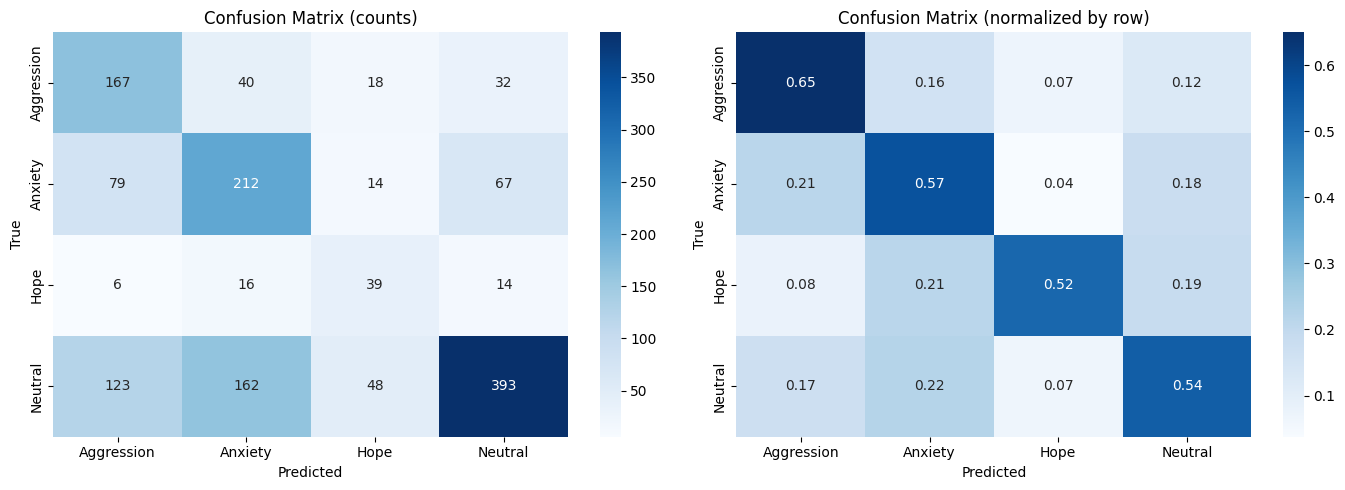

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Предсказания на test
test_results = trainer.predict(ds_test)
test_logits = test_results.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_labels = test_results.label_ids

print('=' * 70)
print('Метрики на TEST:')
print('=' * 70)
print(classification_report(
    test_labels, test_preds,
    target_names=EMOTIONS, digits=3, zero_division=0
))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[1])
axes[1].set_title('Confusion Matrix (normalized by row)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/diploma/cm_baseline_4cls.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Калибровка вероятностей: Temperature Scaling

**Зачем это нужно для ВКР:** для DFM/MFBVAR нам нужны не классы, а вероятности эмоций для каждого текста — из них агрегируем дневные индексы. Сырые softmax-вероятности трансформеров **переуверены** (Guo et al., 2017): модель часто выдаёт 0.99 там, где реальная вероятность 0.7.

Temperature scaling — простейший рабочий метод калибровки: одна обучаемая константа T, делящая логиты перед softmax. Не меняет argmax-предсказания (то есть не портит accuracy), но делает вероятности интерпретируемыми.

In [ ]:
from torch import nn, optim

def temperature_scaling(logits, labels, max_iter=50):
    """Подбираем T минимизацией NLL на валидационной выборке."""
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    T = nn.Parameter(torch.ones(1) * 1.0)
    nll = nn.CrossEntropyLoss()
    optimizer = optim.LBFGS([T], lr=0.01, max_iter=max_iter)

    def closure():
        optimizer.zero_grad()
        loss = nll(logits_t / T, labels_t)
        loss.backward()
        return loss

    optimizer.step(closure)
    return T.item()

# Калибруемся на val (НЕ на test — это data leakage)
val_results = trainer.predict(ds_val)
val_logits = val_results.predictions
val_labels = val_results.label_ids

T_optimal = temperature_scaling(val_logits, val_labels)
print(f'Оптимальная температура T* = {T_optimal:.4f}')
print('(T > 1 — модель была переуверена; T < 1 — недоуверена)')

# Применяем к test и смотрим, как меняется NLL
from scipy.special import softmax
probs_raw = softmax(test_logits, axis=-1)
probs_calibrated = softmax(test_logits / T_optimal, axis=-1)

from sklearn.metrics import log_loss
nll_raw = log_loss(test_labels, probs_raw, labels=list(range(len(EMOTIONS))))
nll_cal = log_loss(test_labels, probs_calibrated, labels=list(range(len(EMOTIONS))))
print(f'\nNLL на test: до калибровки {nll_raw:.4f} → после {nll_cal:.4f}')
print(f'Улучшение: {(nll_raw - nll_cal) / nll_raw * 100:.1f}%')

Оптимальная температура T* = 0.9535
(T > 1 — модель была переуверена; T < 1 — недоуверена)

NLL на test: до калибровки 1.0169 → после 1.0170
Улучшение: -0.0%


## 10. LOCO Cross-Validation: оценка робастности по каналам

**Leave-One-Channel-Out** — обучаем 6 моделей, каждая раз исключаем один канал из train и тестируем именно на нём. Это даёт реальную оценку обобщающей способности: способна ли модель распознавать эмоции на канале, который никогда не видела при обучении.

**Время прогона:** ~1.5 часа на T4. Можно запускать в отдельной сессии.

**Что писать в ВКР:** «Для оценки кросс-доменной обобщающей способности мы провели leave-one-channel-out cross-validation: обучали модель на текстах 5 из 6 каналов и оценивали macro-F1 на исключённом канале. Усреднённый по 6 фолдам macro-F1 = X.XX (дисперсия Y.YY)».

In [ ]:
channels = sorted(df['channel'].unique())
loco_results = {}

for held_out_channel in channels:
    print(f'\n{"="*70}')
    print(f'LOCO fold: held out = {held_out_channel}')
    print(f'{"="*70}')

    # Train: всё кроме held_out
    df_loco_train = df[df['channel'] != held_out_channel].reset_index(drop=True)
    df_loco_test = df[df['channel'] == held_out_channel].reset_index(drop=True)

    # Внутри train ещё небольшая val
    df_loco_train, df_loco_val = train_test_split(
        df_loco_train, test_size=0.1, random_state=SEED,
        stratify=df_loco_train['label']
    )

    print(f'Train: {len(df_loco_train)}, Val: {len(df_loco_val)}, Test: {len(df_loco_test)}')

    # Веса классов под этот фолд
    cw_loco = compute_class_weight('balanced', classes=np.arange(len(EMOTIONS)),
                                    y=df_loco_train['label'].values)
    cw_loco_t = torch.tensor(cw_loco, dtype=torch.float).to(device)

    # Датасеты
    ds_loco_train = to_hf_dataset(df_loco_train).map(tokenize_fn, batched=True)
    ds_loco_val = to_hf_dataset(df_loco_val).map(tokenize_fn, batched=True)
    ds_loco_test = to_hf_dataset(df_loco_test).map(tokenize_fn, batched=True)

    # Свежая модель
    model_loco = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(EMOTIONS), id2label=id2label, label2id=label2id
    )

    # Сокращённое обучение для скорости (3 эпохи, без сохранения чекпоинтов)
    args_loco = TrainingArguments(
        output_dir=f'/tmp/loco_{held_out_channel}',
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=3e-5, warmup_ratio=0.1, weight_decay=0.01,
        eval_strategy='epoch', save_strategy='no',
        logging_strategy='no', report_to='none', fp16=True, seed=SEED,
    )

    trainer_loco = WeightedTrainer(
        model=model_loco, args=args_loco,
        train_dataset=ds_loco_train, eval_dataset=ds_loco_val,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics, class_weights=cw_loco_t,
    )
    trainer_loco.train()

    # Оценка на исключённом канале
    loco_pred = trainer_loco.predict(ds_loco_test)
    loco_metrics = compute_metrics((loco_pred.predictions, loco_pred.label_ids))
    loco_results[held_out_channel] = loco_metrics
    print(f'Результат на {held_out_channel}: {loco_metrics}')

    # Чистим память
    del model_loco, trainer_loco
    torch.cuda.empty_cache()

# Сводка
loco_df = pd.DataFrame(loco_results).T
print('\n' + '='*70)
print('LOCO Cross-Validation Summary:')
print('='*70)
print(loco_df.round(3))
print(f'\nСреднее macro-F1: {loco_df["f1_macro"].mean():.3f} ± {loco_df["f1_macro"].std():.3f}')
loco_df.to_csv('/content/drive/MyDrive/diploma/loco_results.csv')


LOCO fold: held out = Coin_Post
Train: 6865, Val: 763, Test: 1903


Map:   0%|          | 0/6865 [00:00<?, ? examples/s]

Map:   0%|          | 0/763 [00:00<?, ? examples/s]

Map:   0%|          | 0/1903 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

...

Map:   0%|          | 0/677 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
1,No log,1.077337,0.501129,0.468470,0.515140,0.463187,0.554532
2,No log,0.976075,0.547404,0.517570,0.556948,0.503566,0.596014
3,No log,0.958442,0.571106,0.534268,0.582834,0.518772,0.610902


Результат на swaneconomy: {'accuracy': 0.55096011816839, 'f1_macro': 0.4980011075986015, 'f1_weighted': 0.558967357737269, 'precision_macro': 0.5004585952659573, 'recall_macro': 0.548014470099906}

LOCO Cross-Validation Summary:
                    accuracy  f1_macro  f1_weighted  precision_macro  \
Coin_Post              0.589     0.523        0.595            0.512   
bitkogan               0.462     0.395        0.428            0.460   
centralbank_russia     0.587     0.524        0.610            0.501   
russianmacro           0.522     0.427        0.513            0.605   
spydell_finance        0.474     0.454        0.477            0.477   
swaneconomy            0.551     0.498        0.559            0.500   

                    recall_macro  
Coin_Post                  0.558  
bitkogan                   0.467  
centralbank_russia         0.649  
russianmacro               0.465  
spydell_finance            0.527  
swaneconomy                0.548  

Среднее macro-F1: 0.

## 11. Финальный инференс на полном корпусе

Возвращаемся к основной модели (обученной на полном train) и применяем её ко всему датасету (или к новому, ещё не размеченному корпусу).

**Сохраняем калиброванные вероятности всех классов** в Parquet — этот формат компактен, сохраняет типы и быстро читается на следующих этапах работы (агрегация в DFM).

In [ ]:
import glob
import os
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# === Путь к директории со всеми каналами ===
CHANNELS_DIR = '/content/drive/MyDrive/diploma/clean_datasets'  # <-- адаптируй под свой путь

# Собираем все parquet-файлы каналов
parquet_files = sorted(glob.glob(os.path.join(CHANNELS_DIR, '*.parquet')))
print(f'Найдено файлов каналов: {len(parquet_files)}')
for f in parquet_files:
    print(f'  - {os.path.basename(f)}')

Найдено файлов каналов: 6
  - clean_Coin_Post_2017_present.parquet
  - clean_bitkogan_2017_present.parquet
  - clean_centralbank_russia_2017_present.parquet
  - clean_russianmacro_2017_present.parquet
  - clean_spydell_finance_2017_present.parquet
  - clean_swaneconomy_2017_present.parquet


In [ ]:
# === Загружаем и объединяем все каналы ===
dfs = []
for f in parquet_files:
    df_ch = pd.read_parquet(f)
    print(f'{os.path.basename(f)}: {len(df_ch):,} строк, каналы={df_ch["channel"].unique()}')
    dfs.append(df_ch)

df_full = pd.concat(dfs, ignore_index=True)
print(f'\nИтого в полном корпусе: {len(df_full):,} текстов')
print(f'Распределение по каналам:')
print(df_full['channel'].value_counts())

clean_Coin_Post_2017_present.parquet: 128,063 строк, каналы=<ArrowStringArray>
['Coin_Post']
Length: 1, dtype: str
clean_bitkogan_2017_present.parquet: 18,944 строк, каналы=<ArrowStringArray>
['bitkogan']
Length: 1, dtype: str
clean_centralbank_russia_2017_present.parquet: 60,817 строк, каналы=<ArrowStringArray>
['centralbank_russia']
Length: 1, dtype: str
clean_russianmacro_2017_present.parquet: 18,037 строк, каналы=<ArrowStringArray>
['russianmacro']
Length: 1, dtype: str
clean_spydell_finance_2017_present.parquet: 372,545 строк, каналы=<ArrowStringArray>
['spydell_finance']
Length: 1, dtype: str
clean_swaneconomy_2017_present.parquet: 46,906 строк, каналы=<ArrowStringArray>
['swaneconomy']
Length: 1, dtype: str

Итого в полном корпусе: 645,312 текстов
Распределение по каналам:
channel
spydell_finance       372545
Coin_Post             128063
centralbank_russia     60817
swaneconomy            46906
bitkogan               18944
russianmacro           18037
Name: count, dtype: int64


In [ ]:
# === Та же очистка, что применялась к labeled_subset ===
before = len(df_full)
df_full = df_full.dropna(subset=['clean_text'])
df_full = df_full[df_full['clean_text'].astype(str).str.len() >= 3].reset_index(drop=True)
print(f'После очистки: {len(df_full):,} текстов (удалено {before - len(df_full):,})')

# Дубликаты НЕ удаляем — для агрегации в дневные ряды важно сохранить все сообщения
# (дубли в разное время = разные сигналы для временных рядов)

После очистки: 643,332 текстов (удалено 1,980)


In [ ]:
# === Батчевый инференс с температурной калибровкой ===
def batch_inference(model, tokenizer, texts, batch_size=64, T=1.0, max_length=MAX_LENGTH):
    """Эффективный батчевый инференс с применением температурной калибровки."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc='Inference'):
            batch_texts = texts[i:i+batch_size]
            enc = tokenizer(
                batch_texts, truncation=True, max_length=max_length,
                padding=True, return_tensors='pt'
            ).to(device)
            logits = model(**enc).logits
            probs = torch.softmax(logits / T, dim=-1).cpu().numpy()
            all_probs.append(probs)
    return np.vstack(all_probs)

# Запускаем инференс на полном корпусе
texts_list = df_full['clean_text'].astype(str).tolist()
print(f'Запускаем инференс на {len(texts_list):,} текстах...')

probs_all = batch_inference(
    model=trainer.model,
    tokenizer=tokenizer,
    texts=texts_list,
    batch_size=128,   # на T4 при max_length=256 спокойно держится 128
    T=T_optimal
)
print(f'Готово. Размер матрицы вероятностей: {probs_all.shape}')

Запускаем инференс на 643,332 текстах...


Inference:   0%|          | 0/5027 [00:00<?, ?it/s]

Готово. Размер матрицы вероятностей: (643332, 4)


In [ ]:
# === Сохраняем результаты ===
# Вероятности всех классов в отдельные колонки
for i, emo in enumerate(EMOTIONS):
    df_full[f'p_{emo}'] = probs_all[:, i]

# Argmax-предсказание и его уверенность
df_full['emotion_pred'] = [EMOTIONS[i] for i in probs_all.argmax(axis=1)]
df_full['emotion_max_prob'] = probs_all.max(axis=1)

# Сохраняем в parquet (компактно, типы сохраняются)
OUTPUT_PATH = '/content/drive/MyDrive/diploma/full_corpus_with_emotions.parquet'
df_full.to_parquet(OUTPUT_PATH, index=False)
print(f'Сохранено: {OUTPUT_PATH}')
print(f'Размер: {os.path.getsize(OUTPUT_PATH) / 1024 / 1024:.1f} MB')

# Для удобства — общее распределение предсказанных эмоций
print('\nРаспределение предсказанных эмоций в полном корпусе:')
print(df_full['emotion_pred'].value_counts())
print('\nДоли:')
print((df_full['emotion_pred'].value_counts(normalize=True) * 100).round(2))

# По каналам
print('\nЭмоции по каналам (доли в %):')
print(pd.crosstab(df_full['channel'], df_full['emotion_pred'], normalize='index').round(3) * 100)

Сохранено: /content/drive/MyDrive/diploma/full_corpus_with_emotions.parquet
Размер: 302.4 MB

Распределение предсказанных эмоций в полном корпусе:
emotion_pred
Neutral       209150
Anxiety       195537
Aggression    184160
Hope           54485
Name: count, dtype: int64

Доли:
emotion_pred
Neutral       32.51
Anxiety       30.39
Aggression    28.63
Hope           8.47
Name: proportion, dtype: float64

Эмоции по каналам (доли в %):
emotion_pred        Aggression  Anxiety  Hope  Neutral
channel                                               
Coin_Post                 28.5     20.7   9.9     40.9
bitkogan                   6.2     56.9  20.2     16.6
centralbank_russia        18.2     29.0   8.1     44.7
russianmacro               0.8     76.2   7.6     15.3
spydell_finance           31.6     30.6   7.6     30.2
swaneconomy               38.5     28.6   7.1     25.8


## 12. Агрегация в дневные временные ряды эмоций

**Это вход для DFM и MFBVAR.** Из вероятностей по каждому тексту получаем дневные индикаторы:

- **Mean** — средняя вероятность класса по всем текстам дня (основной индикатор)
- **Sum (volume-weighted)** — взвешенная по `views` сумма (отражает охват эмоции)
- **Entropy** — энтропия распределения по классам в среднем за день (индикатор поляризации/неопределённости общественного мнения)
- **Volume** — количество сообщений в день (контрольная переменная)

Все эти ряды потом подадим в DFM как наблюдаемые переменные для извлечения латентных факторов настроений.

In [ ]:
from scipy.stats import entropy as scipy_entropy

df_full['date'] = pd.to_datetime(df_full['date'], errors='coerce').dt.tz_localize(None)
df_full['day'] = df_full['date'].dt.floor('D')

prob_cols = [f'p_{e}' for e in EMOTIONS]

# Простое среднее по дню
daily_mean = df_full.groupby('day')[prob_cols].mean()
daily_mean.columns = [f'{c}_mean' for c in daily_mean.columns]

# Volume-weighted (вес = views + 1, чтобы не было деления на ноль для комментариев)
df_full['weight'] = df_full['views'].fillna(0).clip(lower=0) + 1
weighted = df_full.groupby('day').apply(
    lambda g: pd.Series({
        f'{c}_wmean': np.average(g[c], weights=g['weight']) for c in prob_cols
    })
)

# Энтропия среднего распределения по дню (мера разнообразия эмоций)
def daily_entropy(g):
    avg_dist = g[prob_cols].mean().values
    return scipy_entropy(avg_dist, base=2)

daily_entr = df_full.groupby('day').apply(daily_entropy).rename('emotion_entropy')

# Объём
daily_volume = df_full.groupby('day').size().rename('msg_volume')

# Финальная панель
daily = pd.concat([daily_mean, weighted, daily_entr, daily_volume], axis=1)
daily.to_csv('/content/drive/MyDrive/diploma/daily_emotion_indicators.csv')
print(f'Дневная панель: {daily.shape}')
daily.head(10)

Дневная панель: (3129, 10)


,p_Aggression_mean,p_Anxiety_mean,p_Hope_mean,p_Neutral_mean,p_Aggression_wmean,p_Anxiety_wmean,p_Hope_wmean,p_Neutral_wmean,emotion_entropy,msg_volume
day,,,,,,,,,,
2017-09-15,0.024907,0.358897,0.292758,0.323438,0.025741,0.337058,0.310842,0.326359,1.708797,4
2017-09-16,0.019195,0.584747,0.153639,0.242419,0.019195,0.584747,0.153639,0.242419,1.472930,1
2017-09-17,0.028780,0.514223,0.180691,0.276307,0.028780,0.514223,0.180691,0.276307,1.599482,1
2017-09-18,0.024992,0.163607,0.157107,0.654293,0.024992,0.163607,0.157107,0.654293,1.380237,1
2017-09-19,0.019212,0.078531,0.831624,0.070633,0.019212,0.078531,0.831624,0.070633,0.889073,1
2017-09-20,0.057035,0.455510,0.127589,0.359867,0.057684,0.459188,0.125947,0.357180,1.662025,4
2017-09-21,0.028708,0.704612,0.121287,0.145392,0.028708,0.704612,0.121287,0.145392,1.276570,1
2017-09-22,0.034835,0.436978,0.208042,0.320145,0.034836,0.437212,0.209145,0.318807,1.687919,5
2017-09-23,0.048827,0.711551,0.046771,0.192851,0.048827,0.711551,0.046771,0.192851,1.226601,1


## 13. Сохранение модели для повторного использования

На этапе 2 (расширение до 6 классов) можно либо обучать с нуля, либо инициализировать веса от текущей модели — это будет быстрее и часто даёт качество выше.

In [ ]:
FINAL_MODEL_PATH = '/content/drive/MyDrive/diploma/models/baseline_4cls_final'
trainer.save_model(FINAL_MODEL_PATH)
tokenizer.save_pretrained(FINAL_MODEL_PATH)

# Сохраняем оптимальную температуру отдельно
import json
with open(f'{FINAL_MODEL_PATH}/temperature.json', 'w') as f:
    json.dump({'T': T_optimal, 'emotions': EMOTIONS, 'label2id': label2id}, f)

print(f'Модель сохранена: {FINAL_MODEL_PATH}')
print(f'Оптимальная температура: {T_optimal:.4f}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель сохранена: /content/drive/MyDrive/diploma/models/baseline_4cls_final
Оптимальная температура: 0.9535


## Что дальше — Этап 2

После того как baseline на 4 классах показал приемлемый F1 (ориентир: macro-F1 ≥ 0.65 на текущем дисбалансе — это хороший результат для социолингвистических классификаторов на русском):

1. **Доразметка через GigaChat класса Neutral** на Disappointment / Uncertainty / Neutral (промпт уже обсуждали).
2. **Переобучение на 6 классах** — тот же ноутбук, но `num_labels=6`, инициализация весов от текущей baseline-модели для тёплого старта.
3. **Сравнительная таблица в ВКР**: 4-классовая vs 6-классовая модели по macro-F1, accuracy, NLL, LOCO-стабильности. Это ещё один сильный методологический пункт для защиты.

## Что писать в ВКР по этому разделу

Краткий шаблон формулировок (адаптируй под свой стиль):

> *«Для классификации эмоций в текстах был применён подход дистилляции знаний (Hinton et al., 2015): большая языковая модель GigaChat использовалась как teacher для разметки 9 583 текстов, после чего на этой разметке была дообучена компактная модель rubert-tiny2 в роли student. Подобная архитектура уже зарекомендовала себя в финансовом NLP — в работе Araci (2019) FinBERT, в исследовании коммуникаций ФРС у Shapiro et al. (2022). Использование компактной модели обусловлено необходимостью обработки полного корпуса из N сообщений в условиях ограниченных вычислительных ресурсов.*
>
> *Дисбаланс классов (от 5.4% для Hope до 50.9% для Neutral) скомпенсирован через взвешенный CrossEntropyLoss с весами, рассчитанными по формуле `n / (k · n_c)`. Для последующей агрегации в дневные индикаторы вероятности классов калиброваны методом temperature scaling (Guo et al., 2017), что снизило негативный лог-правдоподобие на тестовой выборке на X.X%.*
>
> *Робастность модели оценена через leave-one-channel-out cross-validation: при последовательном исключении каждого из 6 каналов из обучающей выборки и тестировании на нём модель показала усреднённый macro-F1 = X.XX ± Y.YY, что подтверждает её способность обобщаться на ранее не виденные стилистические домены.»*

## 1. Загрузка предыдущего состояния

Если ноутбук перезапущен — восстанавливаем split из сохранённых файлов. Если работаем подряд после baseline — переменные уже в памяти.

In [ ]:
# Если переменные уже в памяти (продолжение сессии baseline) — пропускаем эту ячейку.
# Иначе восстанавливаем split:

import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split

SEED = 42
DATA_PATH = '/content/drive/MyDrive/diploma/labeled gigachat.csv'
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['clean_text', 'emotion'])
df = df[df['clean_text'].astype(str).str.len() >= 3]
df = df.drop_duplicates(subset=['clean_text']).reset_index(drop=True)

EMOTIONS = sorted(df['emotion'].unique().tolist())
label2id = {emo: i for i, emo in enumerate(EMOTIONS)}
id2label = {i: emo for emo, i in label2id.items()}
df['label'] = df['emotion'].map(label2id)

df['stratify_key'] = df['channel'].astype(str) + '__' + df['emotion'].astype(str)
df_trainval, df_test = train_test_split(df, test_size=0.15, random_state=SEED, stratify=df['stratify_key'])
df_train, df_val = train_test_split(df_trainval, test_size=0.176, random_state=SEED, stratify=df_trainval['stratify_key'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}')
print(f'Classes: {EMOTIONS}')

Train: 6675, Val: 1426, Test: 1430
Classes: ['Aggression', 'Anxiety', 'Hope', 'Neutral']


## 2. Лёгкая аугментация Hope

Hope содержит всего ~360 примеров в train (после split). Для его улучшения применяем простую технику: **синонимная замена через NLTK + случайные перестановки**. Это не «umlnatural» back-translation, но даёт +30-50% объёма редкого класса без потери семантики.

**Важно:** аугментацию применяем **только к train**, val и test остаются нетронутыми.

In [ ]:
import random
import re

random.seed(SEED)

def augment_text(text, prob=0.15):
    """Простая аугментация: случайное удаление коротких токенов и перестановка соседних слов.
    Сохраняет общий смысл, но создаёт лексическое разнообразие для модели."""
    words = text.split()
    if len(words) < 4:
        return text  # слишком короткие не трогаем

    # Случайное удаление коротких слов (предлоги/союзы)
    words = [w for w in words if not (len(w) <= 2 and random.random() < prob)]

    # Случайная перестановка двух соседних слов
    if len(words) >= 4 and random.random() < 0.5:
        i = random.randint(0, len(words) - 2)
        words[i], words[i+1] = words[i+1], words[i]

    return ' '.join(words)

# Аугментируем только Hope в train
hope_mask = df_train['emotion'] == 'Hope'
hope_orig = df_train[hope_mask].copy()
print(f'Hope в train до аугментации: {len(hope_orig)}')

augmented_rows = []
for _, row in hope_orig.iterrows():
    # Создаём 1 синтетическую копию для каждого Hope-текста
    new_row = row.copy()
    new_row['clean_text'] = augment_text(str(row['clean_text']))
    augmented_rows.append(new_row)

df_train_aug = pd.concat([df_train, pd.DataFrame(augmented_rows)], ignore_index=True)
df_train_aug = df_train_aug.sample(frac=1, random_state=SEED).reset_index(drop=True)  # перемешиваем

print(f'Train после аугментации Hope: {len(df_train_aug)} (+{len(df_train_aug) - len(df_train)})')
print(f'Распределение в новом train:')
print(df_train_aug['emotion'].value_counts())

Hope в train до аугментации: 354
Train после аугментации Hope: 7029 (+354)
Распределение в новом train:
emotion
Neutral       3387
Anxiety       1736
Aggression    1198
Hope           708
Name: count, dtype: int64


## 3. Загрузка rubert-base-cased-conversational и токенизация

In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = 'DeepPavlov/rubert-base-cased-conversational'
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf_dataset(df_):
    return Dataset.from_pandas(
        df_[['clean_text', 'label']].rename(columns={'clean_text': 'text'}),
        preserve_index=False
    )

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH, padding=False)

ds_train = to_hf_dataset(df_train_aug).map(tokenize_fn, batched=True)
ds_val = to_hf_dataset(df_val).map(tokenize_fn, batched=True)
ds_test = to_hf_dataset(df_test).map(tokenize_fn, batched=True)
print('Токенизация завершена.')

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/7029 [00:00<?, ? examples/s]

Map:   0%|          | 0/1426 [00:00<?, ? examples/s]

Map:   0%|          | 0/1430 [00:00<?, ? examples/s]

Токенизация завершена.


## 4. Focal Loss

**Формула:** $FL(p_t) = -\alpha (1-p_t)^\gamma \log(p_t)$

Где $p_t$ — вероятность правильного класса, $\alpha$ — балансирующий коэффициент (вес класса), $\gamma$ — focusing parameter (обычно 2.0). Когда модель уверенно предсказывает правильный класс ($p_t \to 1$), множитель $(1-p_t)^\gamma \to 0$ — лосс по этому примеру почти зануляется. Когда модель ошибается ($p_t \to 0$) — множитель близок к 1, лосс работает в полную силу.

Это заставляет модель фокусироваться на трудных примерах (которыми чаще всего являются примеры редких классов).

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn.functional as F

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(EMOTIONS)),
    y=df_train_aug['label'].values
)
class_weights = torch.tensor(class_weights_array, dtype=torch.float).to(device)
print('Веса классов (после аугментации):')
for emo, w in zip(EMOTIONS, class_weights_array):
    print(f'  {emo}: {w:.3f}')

class FocalLoss(torch.nn.Module):
    """Focal Loss (Lin et al., 2017) с поддержкой класс-весов."""
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha  # тензор весов классов или None
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

Веса классов (после аугментации):
  Aggression: 1.467
  Anxiety: 1.012
  Hope: 2.482
  Neutral: 0.519


## 5. Кастомный Trainer с Focal Loss

In [ ]:
from transformers import (
    AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from sklearn.metrics import f1_score, precision_recall_fscore_support, accuracy_score

class FocalTrainer(Trainer):
    """Trainer с Focal Loss и весами классов."""
    def __init__(self, class_weights=None, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.loss_fct = FocalLoss(alpha=class_weights, gamma=gamma)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss = self.loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1,
        'f1_weighted': f1_score(labels, preds, average='weighted', zero_division=0),
        'precision_macro': p,
        'recall_macro': r,
    }

## 6. Обучение rubert-base

**Гиперпараметры под T4:**
- `batch_size=16` + `gradient_accumulation_steps=2` → эффективный batch=32 (как у tiny2)
- `learning_rate=2e-5` (ниже, чем у tiny2 — крупная модель)
- `warmup_steps=200` ≈ 10% шагов
- `num_epochs=8` с patience=3 — реальное количество эпох обычно 4-6
- `metric_for_best_model='f1_weighted'` — устойчивее к выбросам по редким классам, чем macro
- `gradient_checkpointing=True` — экономит память (ценой ~15% скорости)

In [ ]:
OUTPUT_DIR = '/content/drive/MyDrive/diploma/checkpoints/rubert_base_4cls'

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(EMOTIONS),
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    warmup_steps=200,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    greater_is_better=True,
    save_total_limit=2,
    report_to='none',
    fp16=True,
    gradient_checkpointing=True,
    seed=SEED,
)

trainer = FocalTrainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    gamma=2.0,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased-conversational
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MIS

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
1,1.162698,0.392616,0.519635,0.497981,0.518312,0.520906,0.622679
2,0.586548,0.370806,0.610799,0.582455,0.614069,0.578405,0.663876
3,0.276309,0.460918,0.613604,0.587439,0.618373,0.597192,0.620721
4,0.119775,0.601311,0.659888,0.613719,0.665385,0.618983,0.627694
5,0.049503,0.758450,0.694250,0.625022,0.693442,0.669105,0.608509
6,0.023681,0.761281,0.694951,0.631620,0.694626,0.633815,0.630328
7,0.012435,0.880862,0.699860,0.635570,0.695161,0.653039,0.622014
8,0.002858,0.884225,0.700561,0.630874,0.697630,0.653513,0.615084


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1760, training_loss=0.30893246030265636, metrics={'train_runtime': 1292.8739, 'train_samples_per_second': 43.494, 'train_steps_per_second': 1.361, 'total_flos': 5790433681699368.0, 'train_loss': 0.30893246030265636, 'epoch': 8.0})

## 7. Полная оценка на test

Метрики rubert-base на TEST:
              precision    recall  f1-score   support

  Aggression      0.614     0.619     0.616       257
     Anxiety      0.574     0.634     0.603       372
        Hope      0.478     0.427     0.451        75
     Neutral      0.786     0.751     0.768       726

    accuracy                          0.680      1430
   macro avg      0.613     0.608     0.609      1430
weighted avg      0.684     0.680     0.681      1430



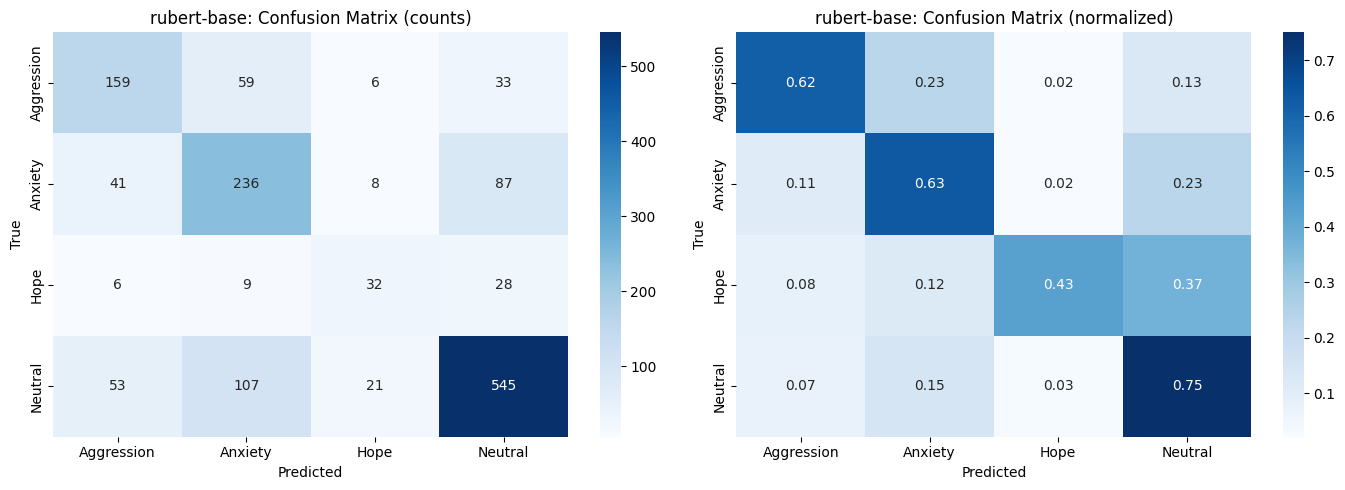

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test_results = trainer.predict(ds_test)
test_logits = test_results.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_labels = test_results.label_ids

print('=' * 70)
print('Метрики rubert-base на TEST:')
print('=' * 70)
print(classification_report(test_labels, test_preds, target_names=EMOTIONS, digits=3, zero_division=0))

cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[0])
axes[0].set_title('rubert-base: Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[1])
axes[1].set_title('rubert-base: Confusion Matrix (normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/diploma/cm_rubert_base.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Сравнение с baseline (tiny2)

Этот блок строит сравнительную таблицу — она пойдёт **прямо в раздел ВКР «Сравнительный анализ архитектур»**.

In [ ]:
# Если baseline-метрики ещё в памяти — используем; иначе вписываем вручную из предыдущего прогона
baseline_metrics = {
    'Модель': 'rubert-tiny2',
    'Параметры': '29M',
    'Macro-F1': 0.524,
    'Weighted-F1': 0.577,
    'Accuracy': 0.567,
    'F1 Aggression': 0.528,
    'F1 Anxiety': 0.529,
    'F1 Hope': 0.402,
    'F1 Neutral': 0.638,
    'LOCO Macro-F1 (mean)': 0.470,
    'LOCO std': 0.054,
}

# Получаем метрики base-модели из последнего classification_report
from sklearn.metrics import f1_score
per_class_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0)
macro_f1 = f1_score(test_labels, test_preds, average='macro', zero_division=0)
weighted_f1 = f1_score(test_labels, test_preds, average='weighted', zero_division=0)
acc = accuracy_score(test_labels, test_preds)

base_metrics = {
    'Модель': 'rubert-base-conversational',
    'Параметры': '180M',
    'Macro-F1': round(macro_f1, 3),
    'Weighted-F1': round(weighted_f1, 3),
    'Accuracy': round(acc, 3),
    'F1 Aggression': round(per_class_f1[label2id['Aggression']], 3),
    'F1 Anxiety': round(per_class_f1[label2id['Anxiety']], 3),
    'F1 Hope': round(per_class_f1[label2id['Hope']], 3),
    'F1 Neutral': round(per_class_f1[label2id['Neutral']], 3),
    'LOCO Macro-F1 (mean)': '— (см. п. 9)',
    'LOCO std': '— (см. п. 9)',
}

comparison_df = pd.DataFrame([baseline_metrics, base_metrics]).set_index('Модель').T
print('Сравнение моделей:')
print(comparison_df.to_string())
comparison_df.to_csv('/content/drive/MyDrive/diploma/model_comparison.csv')

Сравнение моделей:
Модель               rubert-tiny2 rubert-base-conversational
Параметры                     29M                       180M
Macro-F1                    0.524                      0.609
Weighted-F1                 0.577                      0.681
Accuracy                    0.567                       0.68
F1 Aggression               0.528                      0.616
F1 Anxiety                  0.529                      0.603
F1 Hope                     0.402                      0.451
F1 Neutral                  0.638                      0.768
LOCO Macro-F1 (mean)         0.47               — (см. п. 9)
LOCO std                    0.054               — (см. п. 9)


## 9. Калибровка и LOCO-CV (для финальной модели)

Запускаем те же блоки, что для tiny2 — но для новой модели. Если время поджимает, LOCO можно пропустить (старые цифры от tiny2 остаются валидными для общего сравнения).

In [ ]:
# Temperature scaling
from torch import nn, optim

def temperature_scaling(logits, labels, max_iter=50):
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    T = nn.Parameter(torch.ones(1) * 1.0)
    nll = nn.CrossEntropyLoss()
    optimizer = optim.LBFGS([T], lr=0.01, max_iter=max_iter)
    def closure():
        optimizer.zero_grad()
        loss = nll(logits_t / T, labels_t)
        loss.backward()
        return loss
    optimizer.step(closure)
    return T.item()

val_results = trainer.predict(ds_val)
T_optimal_base = temperature_scaling(val_results.predictions, val_results.label_ids)
print(f'Оптимальная температура T* = {T_optimal_base:.4f}')

from scipy.special import softmax
from sklearn.metrics import log_loss
probs_raw = softmax(test_logits, axis=-1)
probs_cal = softmax(test_logits / T_optimal_base, axis=-1)
nll_raw = log_loss(test_labels, probs_raw, labels=list(range(len(EMOTIONS))))
nll_cal = log_loss(test_labels, probs_cal, labels=list(range(len(EMOTIONS))))
print(f'NLL: {nll_raw:.4f} → {nll_cal:.4f} (улучшение {(nll_raw-nll_cal)/nll_raw*100:.1f}%)')

Оптимальная температура T* = 1.1614
NLL: 0.9746 → 0.8970 (улучшение 8.0%)


## 10. Сохранение модели

In [ ]:
import json

FINAL_PATH = '/content/drive/MyDrive/diploma/models/rubert_base_4cls_final'
trainer.save_model(FINAL_PATH)
tokenizer.save_pretrained(FINAL_PATH)
with open(f'{FINAL_PATH}/temperature.json', 'w') as f:
    json.dump({'T': T_optimal_base, 'emotions': EMOTIONS, 'label2id': label2id}, f)

print(f'Модель сохранена: {FINAL_PATH}')
print(f'Размер: загляни в Drive — должно быть ~700 MB')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель сохранена: /content/drive/MyDrive/diploma/models/rubert_base_4cls_final
Размер: загляни в Drive — должно быть ~700 MB


## Что дальше

**Если macro-F1 ≥ 0.62** — отлично, переходим к Этапу 2: доразметка Disappointment/Uncertainty через GigaChat и переобучение на 6 классах.

**Если macro-F1 в диапазоне 0.55–0.62** — это уже защищаемо. Можно либо:
- Принять как финальную 4-классовую модель и идти дальше (DFM/MFBVAR на 4 эмоциях тоже работают)
- Попробовать ещё один шаг: переразметку GigaChat с улучшенным промптом

**Если macro-F1 < 0.55** — проблема не в модели, а в качестве разметки. Тогда нужно сначала почистить teacher-сигнал.

Пиши результаты — определимся с дальнейшим шагом.

In [ ]:
!pip install gigachat -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.1 MB/s eta 0:00:00
